In [ ]:
# Stock market forecasting- Milestone 1, Milestone 2 and Milestone 3
# Importing the necessary libraries
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [ ]:
# Setting the styles for our plots
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"]=(12,6)

In [ ]:
print("=" * 70)
print("MILESTONE 1: COLLECTION OF DATA")
print("=" * 70)

In [ ]:
# Milestone 1
# Collection of data
ticker = 'NVDA'
start_date = '2019-01-01'
end_date = '2024-12-31'
print(f"Fetching {ticker} data from Yahoo Finance API from {start_date} to {end_date}")

nvda= yf.Ticker(ticker)
raw_df = nvda.history(start = start_date , end =end_date)
if raw_df.empty:
  raise RuntimeError("No data received, check ticker and dates or internet connection")
print(f"Dowloaded {len(raw_df)} trading days of data.")
print(f"Columns: {list(raw_df.columns)}")

In [ ]:
print("=" * 70)
print("MILESTONE 1: PREPROCESSING")
print("=" * 70)

In [ ]:
df = raw_df[['Open','High','Low','Close','Volume']].copy()
df['Adj Close'] = raw_df['Close'] # Initially
if 'Adj Close' in raw_df.columns:
  df['Adj Close'] = raw_df['Adj Close']

# Formatting of date time and sorting of data(old to new)
df.index = pd.to_datetime(df.index) # Format - YYYY-MM-DD HH:MM:SS
df = df.sort_index()

# Duplicates data removal
df = df[~df.index.duplicated(keep="first")]

# Checking if the data is present in numeric or not, If not, then convert it
for col in ['Open','High','Close','Low','Volume','Adj Close']:
  if col in df.columns and df[col].dtype == object:
    df[col] = pd.to_numeric(df[col], errors = "coerce") # coerce = NaN value

# Checking for null values
print(df.isnull().sum())

# Current state
print("First few rows")
print(df.head())
print("Basic statistics")
print(df.describe())

In [ ]:
print("=" * 70)
print("MILESTONE 1: MOVING AVERAGES(SOURCE OF MISSING VALUES)")
print("=" * 70)

In [ ]:
df['MA_20'] = df['Close'].rolling(window = 20, min_periods= 20).mean()
df['MA_50'] = df['Close'].rolling(window = 50, min_periods= 50).mean()
print(" After adding MA_20 and MA_50:")
print(f"  -MA_20: First 19 rows will be NaN(need 20 points)")
print(f"  -MA_50: First 49 rows will be NaN(need 50 points)")
print(f"  -Total null values in MA_20: {df['MA_20'].isna().sum()}")
print(f"  -Total null values in MA_50: {df['MA_50'].isna().sum()}")

In [ ]:
# Copying our dataframe into a new variable
df_before = df.copy()

print("=" * 70)
print("MILESTONE 1 COMPLETED")
print("=" * 70)

In [ ]:
print("=" * 70)
print("MILESTONE 2: HANDLING MISSING VALUES(without dropping rows)")
print("=" * 70)

In [ ]:
print("Method Chosen: Expanding Mean(mean of all available data up to that date)")
print(f"  - For MA_20: first 19 NaNs are replaced by expanding mean of close")
print(f"  - For MA_50: first 49 NaNs are replaced by expanding mean of close")

df['MA_20'] = df['MA_20'].fillna(df['Close'].expanding().mean())
df['MA_50'] = df['MA_50'].fillna(df['Close'].expanding().mean())
print(f" After filling: MA_20 nulls = {df['MA_20'].isna().sum()}, MA_50 nulls = {df['MA_50'].isna().sum()}")

In [ ]:
print("=" * 70)
print("MILESTONE 2: OUTLIER DETECTION AND HANDLING")
print("=" * 70)

In [ ]:
# Function to detect and handle outliers(Rolling Z score method):

def rolling_zscore_smooth(series, window=30, threshold=3.0):
    min_periods = int(window / 2)
    roll_mean = series.rolling(window=window, min_periods=min_periods).mean()
    roll_std = series.rolling(window=window, min_periods=min_periods).std()

    roll_mean = roll_mean.fillna(series.expanding().mean())
    roll_std = roll_std.fillna(series.expanding().std()).fillna(0)
    roll_std_safe = roll_std.replace(0, np.nan)

    z = (series - roll_mean) / roll_std_safe
    z = z.fillna(0)
    outliers_mask = z.abs() > threshold

    adjusted = series.copy()
    adjusted[outliers_mask] = roll_mean[outliers_mask] + threshold * roll_std[outliers_mask] * np.sign(z[outliers_mask])

    return adjusted, int(outliers_mask.sum())

outlier_cols = ["Close", "MA_20", "MA_50"]
outlier_counts_before = {}

for col in outlier_cols:
    cleaned_series, n_out = rolling_zscore_smooth(df[col], window=30, threshold=3.0)
    outlier_counts_before[col] = n_out
    df[f"{col}_cleaned"] = cleaned_series
    print(f"  {col}: rolling Z-score outliers (>3σ) adjusted = {n_out}")


# For "after" comparison we use the cleaned series where we did both missing value + outlier handling
df_after = df.copy()

In [ ]:
# For after comparison we will use cleaned series where we handled missing values and outliers
df_after = df.copy()

print("=" * 70)
print("COMPARISON: BEFORE(with missing values and outliers) Vs AFTER(handled)")
print("=" * 70)

In [ ]:
# Dropping the missing values of before dataset for fair stats
before_ma_20 = df_before['MA_20'].dropna()
before_ma_50 = df_before['MA_50'].dropna()
before_close = df_before['Close']

# Before cleaning
print("--Before(dropped missing values in MA and outliers present)--")
print(f"Close count: {before_close.count()}, mean: {before_close.mean():.2f}, std: {before_close.std():.2f}")
print(f"MA_20 count: {before_ma_20.count()}, mean: {before_ma_20.mean():.2f}, std: {before_ma_20.std():.2f}")
print(f"MA_50 count: {before_ma_50.count()}, mean: {before_ma_50.mean():.2f}, std: {before_ma_50.std():.2f}")

# After cleaning
print("\n--After(Missing Values filled with expanding mean and outliers winsorized)--")
print(f"Close_Cleaned count: {df_after['Close_cleaned'].count()}, mean: {df_after['Close_cleaned'].mean():.2f}, std: {df_after['Close_cleaned'].std():.2f}")
print(f"MA_20_Cleaned count: {df_after['MA_20_cleaned'].count()}, mean: {df_after['MA_20_cleaned'].mean():.2f}, std: {df_after['MA_20_cleaned'].std():.2f}")
print(f"MA_50_Cleaned count: {df_after['MA_50_cleaned'].count()}, mean: {df_after['MA_50_cleaned'].mean():.2f}, std: {df_after['MA_50_cleaned'].std():.2f}")

In [ ]:
print("=" * 72)
print("After cleaning, the data becomes more stable, mean value of the columns")
print("becomes realistic and standard deviation has reduced")
print("and our final dataset is ready to make better predictions")
print("=" * 72)

In [ ]:
print("\nGenerating comparison plots...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Close price: Before (raw) vs After (winsorized)
ax1 = axes[0, 0]
ax1.plot(df_before.index, df_before["Close"], alpha=0.7, label="Before (raw)", color="blue")
ax1.plot(df_after.index, df_after["Close_cleaned"], alpha=0.7, label="After (outliers handled)", color="green", linestyle="--")
ax1.set_title("Close Price: Before vs After Outlier Handling")
ax1.set_ylabel("Price ")
ax1.legend()
ax1.tick_params(axis="x", rotation=45)

# 2) MA_20: Before (with NaN) vs After (filled)
ax2 = axes[0, 1]
ax2.plot(df_before.index, df_before["MA_20"], alpha=0.7, label="Before (NaNs)", color="red")
ax2.plot(df_after.index, df_after["MA_20"], alpha=0.7, label="After (filled)", color="green", linestyle="--")
ax2.set_title("MA_20: Before (missing) vs After (missing values handled)")
ax2.set_ylabel("MA_20 ")
ax2.legend()
ax2.tick_params(axis="x", rotation=45)

# 3) MA_50: Before vs After
ax3 = axes[1, 0]
ax3.plot(df_before.index, df_before["MA_50"], alpha=0.7, label="Before (NaNs)", color="red")
ax3.plot(df_after.index, df_after["MA_50"], alpha=0.7, label="After (filled)", color="green", linestyle="--")
ax3.set_title("MA_50: Before (missing) vs After (missing values handled)")
ax3.set_ylabel("MA_50")
ax3.legend()
ax3.tick_params(axis="x", rotation=45)

# 4) Distribution comparison: Close before vs after
ax4 = axes[1, 1]
ax4.hist(df_before['Close'].dropna(), bins=50, alpha=0.3, label="Before (raw Close)", color="blue", density=True)
ax4.hist(df_after["Close_cleaned"], bins=50, alpha=0.3, label="After (handled)", color="green", density=True)
ax4.set_title("Distribution of Close: Before vs After")
ax4.set_ylabel("Probability Density")
ax4.legend()

plt.tight_layout()
plt.savefig("comparison_before_after.png", dpi=150, bbox_inches="tight")
print("Saved: comparison_before_after.png")
plt.show()

In [ ]:
output_df = df[['Open','High','Low','Close','MA_20','MA_50','Volume','Close_cleaned','MA_20_cleaned','MA_50_cleaned']].copy()
output_df.to_csv("nvidia_cleaned_dataset_2019_2024.csv")
print("Cleaned dataset saved to: nvidia_cleaned_dataset_2019_2024.csv")

In [ ]:
# MILESTONE 2: SIMPLE FORECASTING MODEL(LINEAR REGRESSION)
print("\n" + "=" * 70)
print("MILESTONE 2: SIMPLE FORECASTING MODEL (LINEAR REGRESSION)")
print("=" * 70)

# We will predict next-day Close price (Close_cleaned of next day)
model_df = output_df.copy()
model_df["y_next_close"] = model_df["Close_cleaned"].shift(-1)  # target: next day
model_df = model_df.dropna(subset=["y_next_close"])  # drop last row

feature_cols = ["Close_cleaned", "MA_20", "MA_50", "Volume"]
X = model_df[feature_cols].values
y = model_df["y_next_close"].values

# Time-based split (70/15/15)
n_rows_model = len(model_df)
split_70_m = int(n_rows_model * 0.70)
split_85_m = int(n_rows_model * 0.85)

X_train, y_train = X[:split_70_m], y[:split_70_m]
X_val,   y_val   = X[split_70_m:split_85_m], y[split_70_m:split_85_m]
X_test,  y_test  = X[split_85_m:], y[split_85_m:]

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)


# Evaluation metrics
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

print("\nValidation performance:")
print("  MAE :", mean_absolute_error(y_val, y_val_pred))
print("  RMSE:", rmse(y_val, y_val_pred))

print("\nTest performance:")
print("  MAE :", mean_absolute_error(y_test, y_test_pred))
print("  RMSE:", rmse(y_test, y_test_pred))

# Plot actual vs predicted on test set
plt.figure(figsize=(12, 6))
plt.plot(model_df.index[split_85_m:], y_test, label="Actual (next-day Close)", color="blue")
plt.plot(model_df.index[split_85_m:], y_test_pred, label="Predicted (Linear Regression)", color="orange", linestyle="--")
plt.title("Next-day Close Price: Actual vs Predicted (Test Set)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.savefig("linear_regression_test_predictions.png", dpi=150, bbox_inches="tight")
print("Saved: linear_regression_test_predictions.png")
plt.show()


In [ ]:
print("=" * 70)
print("MILESTONE 2 COMPLETED")
print("=" * 70)

In [ ]:
print("=" * 70)
print("SUMMARY")
print("=" * 70)
print("""
MILESTONE 1:
      - Collection of NVIDIA data (from 01/01/2019 to 31/12/2024))
      - Preprocessing: Standarized columns, datetime index, removed duplicates, ensured numeric types, added moving averages.

MILESTONE 2:
      - Missing Values caused by 20 day and 50 day moving average(first 19 and 49 rows)
      - Handled: filled with expanded mean (without dropping rows)
      - Outliers: Detected with a rolling Z-score (3-sigma) on a 30-day window; extreme values are pulled back toward the local mean (trend-preserving smoothing, no rows dropped).
      - Result: Before Vs After Comparison shows same rows count, statistics and plot show the effect of handling
      - Cleaned dataset is saved for use in later milestones
      - Chronological split created: 70% train, 15% validation, 15% test
      - Trained using Linear Regression and calculated MAE and RMSE for evaluation metrics
      """)

In [ ]:
print("\n" + "=" * 70)
print("MILESTONE 3: ADVANCED MODEL COMPARISON")
print("=" * 70)

In [ ]:
# Feature Engineering
output_df["Return"] = output_df["Close_cleaned"].pct_change()

output_df["MA_10"] = output_df["Close_cleaned"].rolling(10).mean()
output_df["MA_20"] = output_df["Close_cleaned"].rolling(20).mean()
output_df["MA_50"] = output_df["Close_cleaned"].rolling(50).mean()

output_df["Volatility"] = output_df["Return"].rolling(10).std()

output_df["Momentum"] = output_df["Close_cleaned"] - output_df["Close_cleaned"].shift(5)

# Lag features (VERY IMPORTANT)
output_df["Lag1"] = output_df["Close_cleaned"].shift(1)
output_df["Lag2"] = output_df["Close_cleaned"].shift(2)
output_df["Lag3"] = output_df["Close_cleaned"].shift(3)

# RSI (Relative Strength Index)
delta = output_df["Close_cleaned"].diff()

gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss

output_df["RSI"] = 100 - (100/(1+rs))

output_df = output_df.dropna()

In [ ]:
# Target Variable(Next Day Price)

model_df = output_df.copy()

model_df["y_next_close"] = model_df["Close_cleaned"].shift(-1)

model_df = model_df.dropna()

In [ ]:
# Feature Selection

feature_cols = [
    "Close_cleaned",
    "MA_10",
    "MA_20",
    "MA_50",
    "Volume",
    "Return",
    "Volatility",
    "Momentum",
    "RSI",
    "Lag1",
    "Lag2",
    "Lag3"
]

X = model_df[feature_cols]
y = model_df["y_next_close"]

In [ ]:
# Data Splitting
n = len(model_df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X[:train_end]
X_val = X[train_end:val_end]
X_test = X[val_end:]

y_train = y[:train_end]
y_val = y[train_end:val_end]
y_test = y[val_end:]

In [ ]:
# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# RMSE calculation function
def rmse(y_true, y_pred):
  return np.sqrt(mean_squared_error(y_true,y_pred))

In [ ]:
# Linear Regression
print("Training Linear Regression")

lin_model = LinearRegression()

lin_model.fit(X_train_scaled,y_train)

lin_val_pred = lin_model.predict(X_val_scaled)
lin_test_pred = lin_model.predict(X_test_scaled)

lin_mae = mean_absolute_error(y_val,lin_val_pred)
lin_rmse = rmse(y_val,lin_val_pred)
print("Model Trained")
print(f"Mean Absolute Error: {lin_mae}")
print(f"Root Mean Square Error: {lin_rmse}")

In [ ]:
# Random Forest
print("Training Random Forest")

rf_model = RandomForestRegressor(
    n_estimators = 400,
    max_depth = 10,
    min_samples_split = 5,
    random_state = 42,
    n_jobs = -1
)

rf_model.fit(X_train,y_train)

rf_val_pred = rf_model.predict(X_val)
rf_test_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_val,rf_val_pred)
rf_rmse = rmse(y_val,rf_val_pred)
print("Model Trained")
print(f"Mean Absolute Error: {rf_mae}")
print(f"Root Mean Square Error: {rf_rmse}")

In [ ]:
# Gradient Boosting
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=200, learning_rate=0.05,
    max_depth=4, random_state=42
)
gb_model.fit(X_train_scaled, y_train)
gb_val_pred  = gb_model.predict(X_val_scaled)
gb_test_pred = gb_model.predict(X_test_scaled)

gb_mae  = mean_absolute_error(y_val, gb_val_pred)
gb_rmse = rmse(y_val, gb_val_pred)
print(f"Gradient Boosting — MAE: {gb_mae:.3f}, RMSE: {gb_rmse:.3f}")

In [ ]:
# XGBoost
print("Training XGBoost")

xgb_model = XGBRegressor(
    n_estimators = 500,
    learning_rate = 0.03,
    max_depth = 5,
    subsample = 0.9,
    colsample_bytree = 0.9,
    random_state = 42
)

xgb_model.fit(X_train_scaled,y_train)

xgb_val_pred = xgb_model.predict(X_val_scaled)
xgb_test_pred = xgb_model.predict(X_test_scaled)

xgb_mae = mean_absolute_error(y_val,xgb_val_pred)
xgb_rmse = rmse(y_val,xgb_val_pred)
print("Model Trained")
print(f"Mean Absolute Error: {xgb_mae}")
print(f"Root Mean Square Error: {xgb_rmse}")

In [ ]:
# Model Comparison
results = pd.DataFrame({
    "Model":["Linear Regression","Random Forest","XGBoost","Gradient Boosting"],
    "MAE":[lin_mae,rf_mae,xgb_mae,gb_mae],
    "RMSE":[lin_rmse,rf_rmse,xgb_rmse,gb_rmse]
})

results = results.sort_values("RMSE")

print("\nMODEL PERFORMANCE")
print(results.to_string(index=False))

In [ ]:
# Best Model Selection
best_model = results.iloc[0]["Model"]

print("\nBest Model:",best_model)

if best_model == "Random Forest":
  best_predictions = rf_test_pred

elif best_model == "XGBoost":
  best_predictions = xgb_test_pred

elif best_model == "Gradient Boosting":
  best_predictions = gb_test_pred

else:
  best_predictions = lin_test_pred


In [ ]:
print("\n" + "="*70)
print("FINAL 7-DAY FORECAST USING BEST MODEL")
print("="*70)

forecast_days = 7

# Copy last rows to build future predictions
forecast_df = output_df.copy()

future_predictions = []
future_dates = []

for i in range(forecast_days):

    # Select latest row
    latest = forecast_df.iloc[-1]

    # Create feature row
    features = latest[feature_cols].to_frame().T


    # Apply scaling if required
    if best_model == "Random Forest":
        pred = rf_model.predict(features)[0]

    elif best_model == "XGBoost":
        features_scaled = scaler.transform(features)
        pred = xgb_model.predict(features_scaled)[0]

    elif best_model == "Gradient Boosting":
        feature_scaled = scaler.transform(features)
        pred = gb_model.predict(features_scaled)[0]

    else:
        features_scaled = scaler.transform(features)
        pred = lin_model.predict(features_scaled)[0]

    future_predictions.append(pred)

    # Create next row
    next_row = latest.copy()
    next_row["Close_cleaned"] = pred

    # Update lag features
    next_row["Lag3"] = latest["Lag2"]
    next_row["Lag2"] = latest["Lag1"]
    next_row["Lag1"] = pred

    # Append row
    forecast_df = pd.concat([forecast_df, pd.DataFrame([next_row])])

    # Recalculate indicators
    forecast_df["Return"] = forecast_df["Close_cleaned"].pct_change()

    forecast_df["MA_10"] = forecast_df["Close_cleaned"].rolling(10).mean()
    forecast_df["MA_20"] = forecast_df["Close_cleaned"].rolling(20).mean()
    forecast_df["MA_50"] = forecast_df["Close_cleaned"].rolling(50).mean()

    forecast_df["Volatility"] = forecast_df["Return"].rolling(10).std()

    forecast_df["Momentum"] = forecast_df["Close_cleaned"] - forecast_df["Close_cleaned"].shift(5)

    # RSI recalculation
    delta = forecast_df["Close_cleaned"].diff()

    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)

    avg_gain = gain.rolling(14).mean()
    avg_loss = loss.rolling(14).mean()

    rs = avg_gain / avg_loss

    forecast_df["RSI"] = 100 - (100/(1+rs))

    # Generate future business dates
    last_date = model_df.index[-1]

    future_dates = pd.date_range(
    start=last_date + pd.tseries.offsets.BDay(1),
    periods=7,
    freq="B"
    )


future_result = pd.DataFrame({
    "Date": future_dates,
    "Forecast_Price": future_predictions
})

# Clean date format
future_result["Date"] = future_result["Date"].dt.strftime("%Y-%m-%d")

print("\n7 DAY FORECAST PRICE:")
print(future_result)

In [ ]:
print("\nGenerating Forecast Chart...")

plt.figure(figsize=(9,5))

# Remove timezone
future_result["Date"] = pd.to_datetime(future_result["Date"]).dt.tz_localize(None)

# Historical price
plt.plot(
    output_df.index[-60:].tz_localize(None),
    output_df["Close_cleaned"].iloc[-60:],
    label="Historical Price"
)

# Forecast price
plt.plot(
    future_result["Date"],
    future_result["Forecast_Price"],
    marker='o',
    linestyle='--',
    label="7 Day Forecast"
)

plt.title("NVDA Stock Price Forecast (Next 7 Days)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.tight_layout()

plt.savefig("nvda_7_day_forecast.png", dpi=150)

print("Saved: nvda_7_day_forecast.png")

plt.show()


TREND SECTION 1: TREND CLASSIFICATION

Sample: Actual vs Predicted Trend (first 10 test rows):
Actual_Trend LinReg_Trend RandomForest_Trend XGBoost_Trend
        Down         Down               Down          Down
        Down           Up               Down          Down
        Down         Down               Down          Down
          Up           Up               Down          Down
          Up           Up               Down          Down
          Up         Down               Down          Down
        Down         Down               Down          Down
        Down         Down               Down          Down
          Up         Down               Down          Down
          Up           Up               Down          Down

TREND SECTION 2: NAIVE DIRECTIONAL ACCURACY (Regressors)

Model                    Directional Accuracy
----------------------------------------------
Linear Regression                      48.86%
Random Forest                          46.12%
XGBoost    

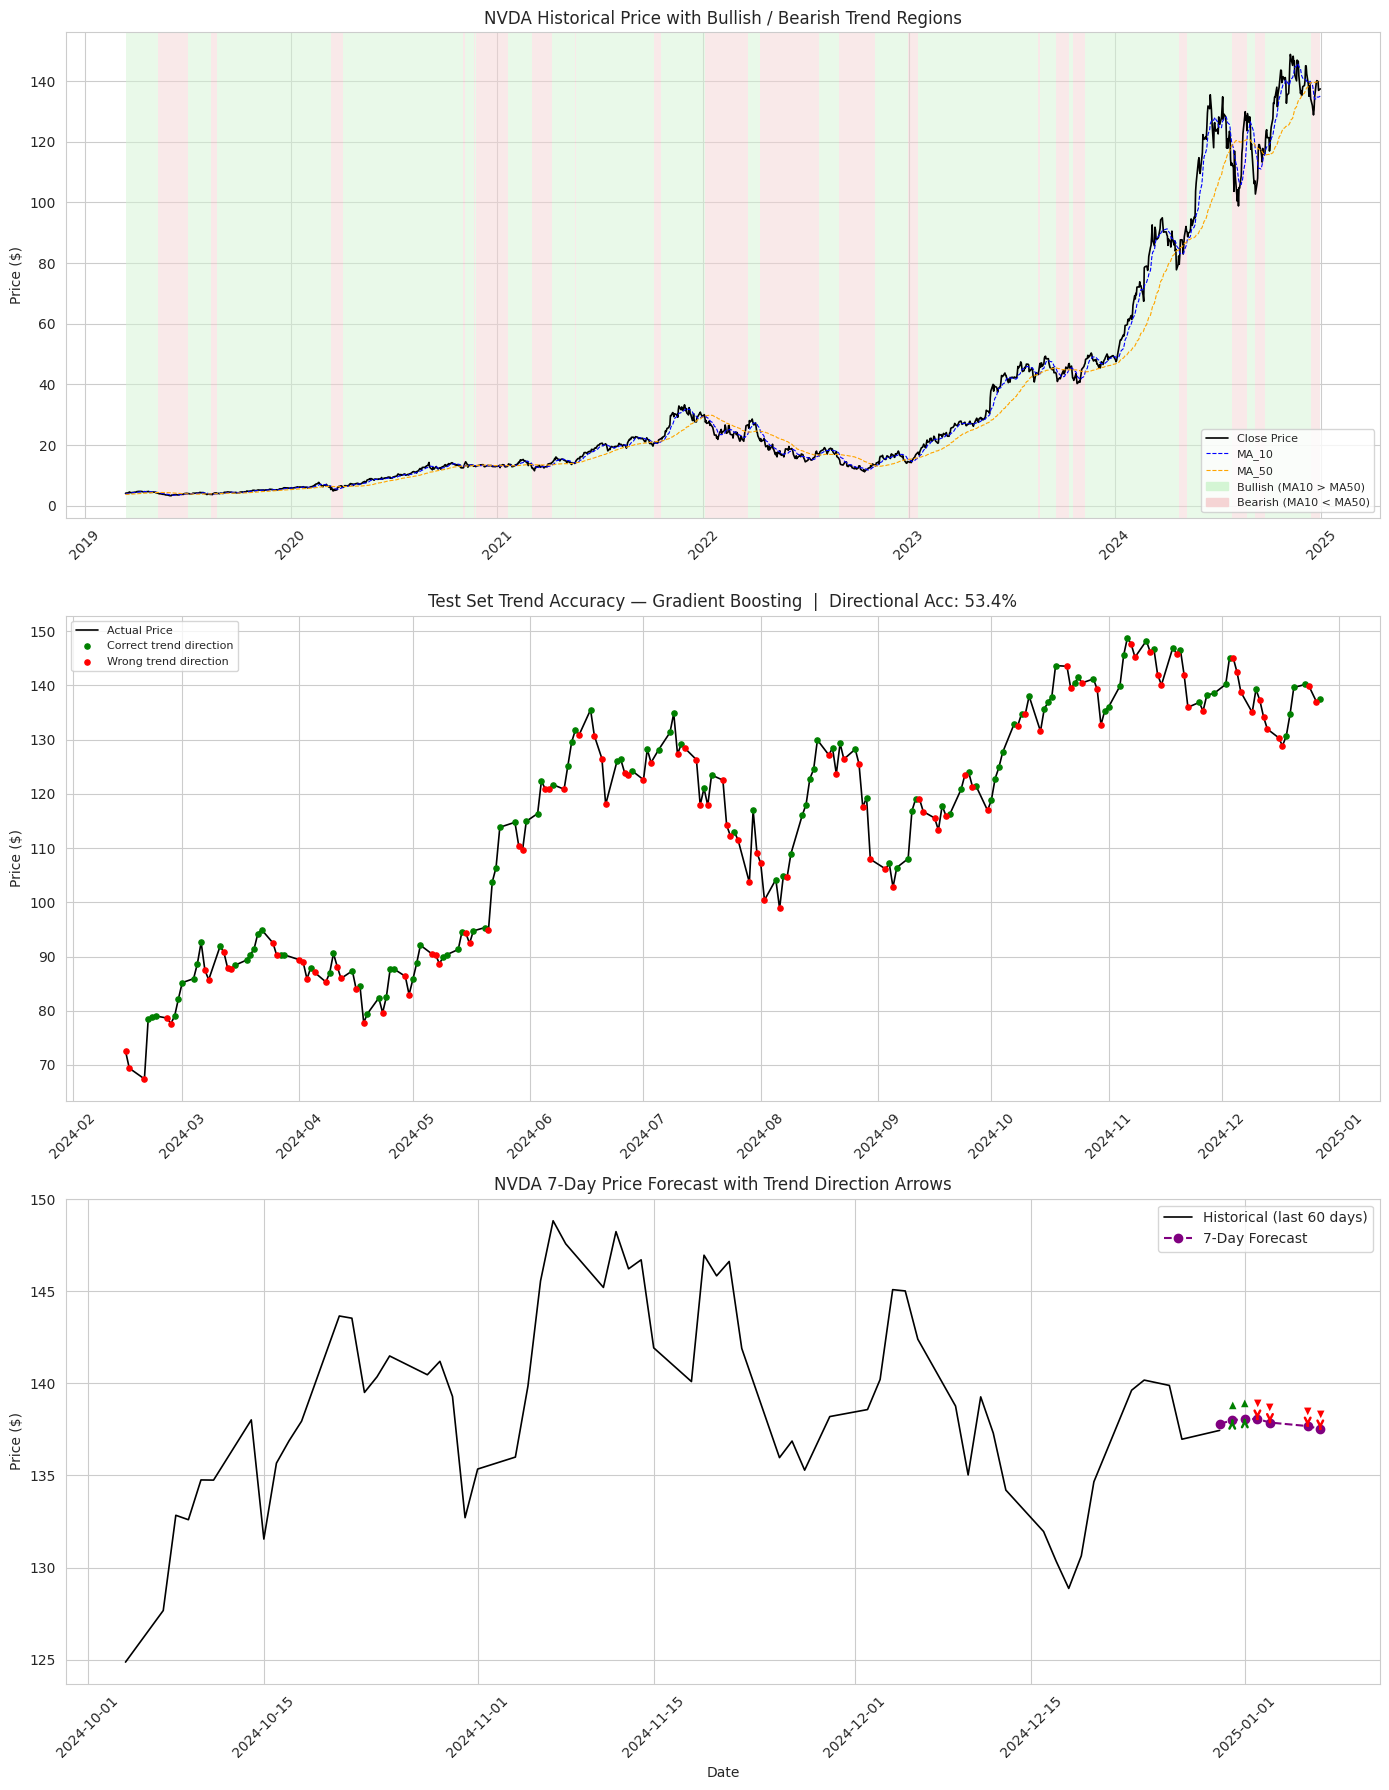

  Saved: improved_trend_accuracy.png


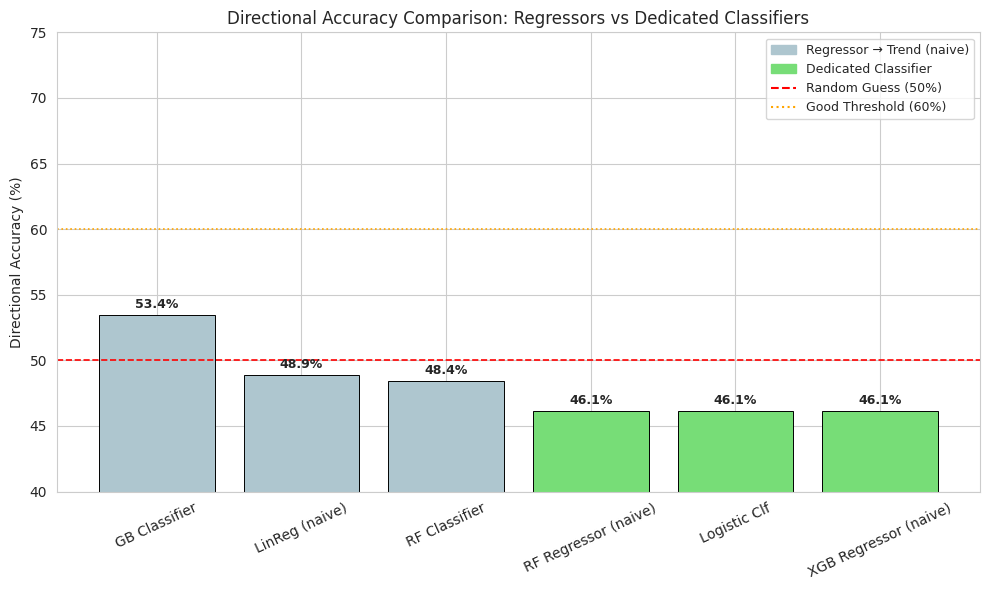


TREND SECTION COMPLETE

  Best Classifier         : Gradient Boosting
  Test Directional Acc    : 53.42%
  Improvement over LinReg : +4.57%
  7-Day Forecast Trend    : Up → Up → Down → Down → Down → Down
 Both models saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
# ============================================================
#   - Trend Classification
#   - Trend Visualization (historical shading, test dots, forecast arrows)
#   - Directional Accuracy (naive + threshold + dedicated classifiers)
#   - Full comparison summary
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.patches as mpatches

# ============================================================
print("\n" + "=" * 70)
print("TREND SECTION 1: TREND CLASSIFICATION")
print("=" * 70)
# ============================================================

# Labelled actual trend direction
# Rule: if next-day price > today's price → Up (1), else Down (0)
model_df["Actual_Trend"] = (model_df["y_next_close"] > model_df["Close_cleaned"]).astype(int)

# Predict trend direction from each regressor's test predictions
actual_prices_test = X_test["Close_cleaned"].values
actual_trend_test  = (y_test.values > actual_prices_test).astype(int)

lin_trend_pred = (lin_test_pred  > actual_prices_test).astype(int)
rf_trend_pred  = (rf_test_pred   > actual_prices_test).astype(int)
xgb_trend_pred = (xgb_test_pred  > actual_prices_test).astype(int)

label_map = {1: "Up", 0: "Down"}

print("\nSample: Actual vs Predicted Trend (first 10 test rows):")
sample = pd.DataFrame({
    "Actual_Trend"        : [label_map[v] for v in actual_trend_test[:10]],
    "LinReg_Trend"        : [label_map[v] for v in lin_trend_pred[:10]],
    "RandomForest_Trend"  : [label_map[v] for v in rf_trend_pred[:10]],
    "XGBoost_Trend"       : [label_map[v] for v in xgb_trend_pred[:10]],
})
print(sample.to_string(index=False))

# ============================================================
print("\n" + "=" * 70)
print("TREND SECTION 2: NAIVE DIRECTIONAL ACCURACY (Regressors)")
print("=" * 70)
# ============================================================

old_lin_acc = accuracy_score(actual_trend_test, lin_trend_pred) * 100
old_rf_acc  = accuracy_score(actual_trend_test, rf_trend_pred)  * 100
old_xgb_acc = accuracy_score(actual_trend_test, xgb_trend_pred) * 100

print(f"\n{'Model':<22} {'Directional Accuracy':>22}")
print("-" * 46)
print(f"{'Linear Regression':<22} {old_lin_acc:>21.2f}%")
print(f"{'Random Forest':<22} {old_rf_acc:>21.2f}%")
print(f"{'XGBoost':<22} {old_xgb_acc:>21.2f}%")
print("\n  Note: These are naive — direction is derived from price predictions,")
print("  not trained directly on Up/Down labels.")

# ============================================================
print("\n" + "=" * 70)
print("TREND SECTION 3: THRESHOLD FILTER (ignore small price moves)")
print("=" * 70)
# ============================================================

THRESHOLD = 0.005  # 0.5% minimum move to count as Up or Down

def classify_with_threshold(pred_prices, actual_prices, threshold=THRESHOLD):
    pred_change   = (pred_prices - actual_prices) / (actual_prices + 1e-9)
    actual_change = np.diff(actual_prices, prepend=actual_prices[0]) / (actual_prices + 1e-9)
    pred_labels   = np.where(pred_change >  threshold, 1,
                    np.where(pred_change < -threshold, 0, -1))
    actual_labels = np.where(actual_change >  threshold, 1,
                    np.where(actual_change < -threshold, 0, -1))
    valid_mask    = actual_labels != -1
    return pred_labels, actual_labels, valid_mask

print(f"\n  Threshold = {THRESHOLD*100:.1f}% — moves smaller than this are treated as noise.\n")

for name, preds in [("Linear Regression", lin_test_pred),
                    ("Random Forest",     rf_test_pred),
                    ("XGBoost",           xgb_test_pred)]:
    pred_lbl, act_lbl, mask = classify_with_threshold(preds, actual_prices_test)
    non_neutral = (pred_lbl[mask] != -1)
    if non_neutral.sum() > 0:
        acc = accuracy_score(act_lbl[mask][non_neutral], pred_lbl[mask][non_neutral]) * 100
        print(f"  {name:<22} | Threshold Acc: {acc:.2f}%  "
              f"(on {non_neutral.sum()} significant moves)")
    else:
        print(f"  {name}: No significant moves found.")

# ============================================================
print("\n" + "=" * 70)
print("TREND SECTION 4: DEDICATED TREND CLASSIFIERS")
print("=" * 70)
# ============================================================

print("  Training classification models directly on Up/Down labels...\n")

# Build classification target
y_cls       = (model_df["y_next_close"] > model_df["Close_cleaned"]).astype(int)
y_cls_train = y_cls.iloc[:train_end]
y_cls_val   = y_cls.iloc[train_end:val_end]
y_cls_test  = y_cls.iloc[val_end:]

# 1. Logistic Regression
log_clf = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
log_clf.fit(X_train_scaled, y_cls_train)
log_val_pred  = log_clf.predict(X_val_scaled)
log_test_pred = log_clf.predict(X_test_scaled)
log_val_acc   = accuracy_score(y_cls_val, log_val_pred) * 100
log_test_acc  = accuracy_score(y_cls_test, log_test_pred) * 100
print(f"  Logistic Regression  | Val: {log_val_acc:.2f}%  | Test: {log_test_acc:.2f}%")

# 2. Random Forest Classifier
rf_clf = RandomForestClassifier(
    n_estimators=400, max_depth=10,
    min_samples_split=5, random_state=42, n_jobs=-1, class_weight='balanced'
)
rf_clf.fit(X_train, y_cls_train)
rf_clf_val_pred  = rf_clf.predict(X_val)
rf_clf_test_pred = rf_clf.predict(X_test)
rf_clf_val_acc   = accuracy_score(y_cls_val,  rf_clf_val_pred)  * 100
rf_clf_test_acc  = accuracy_score(y_cls_test, rf_clf_test_pred) * 100
print(f"  RF Classifier        | Val: {rf_clf_val_acc:.2f}%  | Test: {rf_clf_test_acc:.2f}%")

from sklearn.utils.class_weight import compute_sample_weight

# Gradient Boosting Classifier
gb_clf = GradientBoostingClassifier(
    n_estimators=300, learning_rate=0.05,
    max_depth=4, random_state=42
)

# Compute sample weights to balance classes
sample_weights = compute_sample_weight(class_weight='balanced', y=y_cls_train)

gb_clf.fit(X_train_scaled, y_cls_train, sample_weight=sample_weights)
gb_clf_val_pred  = gb_clf.predict(X_val_scaled)
gb_clf_test_pred = gb_clf.predict(X_test_scaled)
gb_clf_val_acc   = accuracy_score(y_cls_val,  gb_clf_val_pred)  * 100
gb_clf_test_acc  = accuracy_score(y_cls_test, gb_clf_test_pred) * 100
print(f"  Gradient Boosting    | Val: {gb_clf_val_acc:.2f}%  | Test: {gb_clf_test_acc:.2f}%")

# Pick best classifier by validation accuracy
clf_results = {
    "Logistic Regression" : (log_val_acc,    log_test_pred,    log_test_acc),
    "RF Classifier"       : (rf_clf_val_acc, rf_clf_test_pred, rf_clf_test_acc),
    "Gradient Boosting"   : (gb_clf_val_acc, gb_clf_test_pred, gb_clf_test_acc),
}
best_clf_name = max(clf_results, key=lambda k: clf_results[k][0])
best_clf_test = clf_results[best_clf_name][1]
best_clf_test_acc = clf_results[best_clf_name][2]

print(f"\n  Best Classifier: {best_clf_name} (Val: {clf_results[best_clf_name][0]:.2f}% | Test: {best_clf_test_acc:.2f}%)")
print(f"\n  Detailed Classification Report — {best_clf_name} (Test Set):")
print(classification_report(y_cls_test, best_clf_test, target_names=["Down", "Up"], zero_division=0))

# ============================================================
print("\n" + "=" * 70)
print("TREND SECTION 5: FULL COMPARISON SUMMARY")
print("=" * 70)
# ============================================================

summary = pd.DataFrame({
    "Method"               : ["LinReg (naive)", "RF Regressor (naive)", "XGB Regressor (naive)",
                               "Logistic Clf",  "RF Classifier",        "GB Classifier"],
    "Directional Acc (%)"  : [old_lin_acc, old_rf_acc, old_xgb_acc,
                               log_test_acc, rf_clf_test_acc, gb_clf_test_acc],
    "Type"                 : ["Regressor→Trend"] * 3 + ["Dedicated Classifier"] * 3
})
summary = summary.sort_values("Directional Acc (%)", ascending=False).reset_index(drop=True)
print("\n")
print(summary.to_string(index=False))
print(f"\n  Improvement over naive Linear Regression: "
      f"+{best_clf_test_acc - old_lin_acc:.2f}%")

# ============================================================
print("\n" + "=" * 70)
print("TREND SECTION 6: VISUALIZATIONS")
print("=" * 70)
# ============================================================

print("\n  Generating trend charts...")

# ── Figure 1: Historical price with trend shading + test dots + forecast ─────
fig, axes = plt.subplots(3, 1, figsize=(14, 18))

# --- Plot 1: Historical price with bullish/bearish shading ---
ax1 = axes[0]
dates = output_df.index.tz_localize(None) if output_df.index.tz else output_df.index
ax1.plot(dates, output_df["Close_cleaned"], color="black", linewidth=1.2, label="Close Price")

bullish = output_df["MA_10"] > output_df["MA_50"]
for i in range(1, len(output_df)):
    color = "#d4f5d4" if bullish.iloc[i] else "#f5d4d4"
    ax1.axvspan(dates[i - 1], dates[i], color=color, alpha=0.5, linewidth=0)

ax1.plot(dates, output_df["MA_10"], color="blue",   linewidth=0.8, linestyle="--", label="MA_10")
ax1.plot(dates, output_df["MA_50"], color="orange",  linewidth=0.8, linestyle="--", label="MA_50")
green_patch = mpatches.Patch(color="#d4f5d4", label="Bullish (MA10 > MA50)")
red_patch   = mpatches.Patch(color="#f5d4d4", label="Bearish (MA10 < MA50)")
ax1.legend(handles=[*ax1.get_legend_handles_labels()[0], green_patch, red_patch], fontsize=8)
ax1.set_title("NVDA Historical Price with Bullish / Bearish Trend Regions")
ax1.set_ylabel("Price ($)")
ax1.tick_params(axis="x", rotation=45)

# --- Plot 2: Test set — actual price + best classifier trend dots ---
ax2 = axes[1]
test_dates = (model_df.index[val_end:].tz_localize(None)
              if model_df.index.tz else model_df.index[val_end:])

ax2.plot(test_dates, y_test.values, color="black", linewidth=1.2, label="Actual Price")

correct_mask = best_clf_test == y_cls_test.values
ax2.scatter(test_dates[correct_mask],  y_test.values[correct_mask],
            color="green", s=14, zorder=5, label="Correct trend direction")
ax2.scatter(test_dates[~correct_mask], y_test.values[~correct_mask],
            color="red",   s=14, zorder=5, label="Wrong trend direction")

ax2.set_title(f"Test Set Trend Accuracy — {best_clf_name}  |  "
              f"Directional Acc: {best_clf_test_acc:.1f}%")
ax2.set_ylabel("Price ($)")
ax2.legend(fontsize=8)
ax2.tick_params(axis="x", rotation=45)

# --- Plot 3: 7-day forecast with directional arrows ---
ax3 = axes[2]
hist_dates  = output_df.index[-60:].tz_localize(None) if output_df.index.tz else output_df.index[-60:]
hist_prices = output_df["Close_cleaned"].iloc[-60:].values

future_result["Date"] = pd.to_datetime(future_result["Date"]).dt.tz_localize(None)

ax3.plot(hist_dates, hist_prices, color="black", linewidth=1.2, label="Historical (last 60 days)")
ax3.plot(future_result["Date"], future_result["Forecast_Price"],
         marker="o", linestyle="--", color="purple", linewidth=1.5, label="7-Day Forecast")

for i in range(1, len(future_result)):
    x_pos   = future_result["Date"].iloc[i]
    y_start = future_result["Forecast_Price"].iloc[i - 1]
    y_end   = future_result["Forecast_Price"].iloc[i]
    color   = "green" if y_end >= y_start else "red"
    ax3.annotate("", xy=(x_pos, y_end), xytext=(x_pos, y_start),
                 arrowprops=dict(arrowstyle="->", color=color, lw=1.8))
    trend = "▲" if y_end >= y_start else "▼"
    ax3.text(x_pos, y_end * 1.005, trend,
             ha="center", fontsize=7, color=color, fontweight="bold")

ax3.set_title("NVDA 7-Day Price Forecast with Trend Direction Arrows")
ax3.set_ylabel("Price ($)")
ax3.set_xlabel("Date")
ax3.legend(fontsize=10)
ax3.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("trend_visualization.png", dpi=150, bbox_inches="tight")
print("  Saved: trend_visualization.png")
plt.show()

# ── Figure 2: Bar chart — all models directional accuracy comparison ─────────
fig2, ax4 = plt.subplots(figsize=(10, 6))

colors = ["#aec6cf"] * 3 + ["#77dd77"] * 3
bars = ax4.bar(summary["Method"], summary["Directional Acc (%)"],
               color=colors, edgecolor="black", linewidth=0.7)
ax4.axhline(50, color="red",    linestyle="--", linewidth=1.2)
ax4.axhline(60, color="orange", linestyle=":",  linewidth=1.2)

for bar, val in zip(bars, summary["Directional Acc (%)"]):
    ax4.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f"{val:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax4.set_title("Directional Accuracy Comparison: Regressors vs Dedicated Classifiers")
ax4.set_ylabel("Directional Accuracy (%)")
ax4.set_ylim(40, max(summary["Directional Acc (%)"].max() + 8, 75))
ax4.tick_params(axis="x", rotation=25)
ax4.legend(handles=[
    mpatches.Patch(color="#aec6cf", label="Regressor → Trend (naive)"),
    mpatches.Patch(color="#77dd77", label="Dedicated Classifier"),
    plt.Line2D([0], [0], color="red",    linestyle="--", label="Random Guess (50%)"),
    plt.Line2D([0], [0], color="orange", linestyle=":",  label="Good Threshold (60%)"),
], fontsize=9)

plt.tight_layout()
plt.savefig("improved_trend_accuracy.png", dpi=150, bbox_inches="tight")
print("  Saved: improved_trend_accuracy.png")
plt.show()
# ============================================================
print("\n" + "=" * 70)
print("TREND SECTION COMPLETE")
print("=" * 70)

forecast_trends = [
    "Up" if future_result["Forecast_Price"].iloc[i] > future_result["Forecast_Price"].iloc[i - 1]
    else "Down"
    for i in range(1, len(future_result))
]
print(f"\n  Best Classifier         : {best_clf_name}")
print(f"  Test Directional Acc    : {best_clf_test_acc:.2f}%")
print(f"  Improvement over LinReg : +{best_clf_test_acc - old_lin_acc:.2f}%")
print(f"  7-Day Forecast Trend    : {' → '.join(forecast_trends)}")
print("=" * 70)

import joblib
best_regression_model = best_model
best_classifier = best_clf_name


joblib.dump(best_regression_model, 'best_regression_model.pkl')
joblib.dump(best_classifier, 'best_classifier.pkl')

print(" Both models saved!")


from google.colab import files
files.download('best_regression_model.pkl')
files.download('best_classifier.pkl')

In [ ]:
print("=" * 70)
print("MILESTONE 3 COMPLETED")
print("=" * 70)

In [ ]:
print("Summary for MILESTONE 3:")
print("""
• Feature Engineering: Created financial indicators such as Returns, MA10, MA20, MA50, Volatility, Momentum, Lag1–Lag3, and RSI to capture market trends and behavior.
• Data Splitting & Scaling: The dataset was split chronologically into 70% training, 15% validation, and 15% testing sets, and StandardScaler was applied to normalize feature values.
• Model Training: Four machine learning models were trained for prediction — Linear Regression, Random Forest Regressor, XGBoost Regressor, and Gradient Boosting.
• Model Evaluation: Models were evaluated using MAE (Mean Absolute Error) and RMSE (Root Mean Squared Error) to measure prediction accuracy.
• Best Model Selection: The model with the lowest RMSE was selected as the best-performing model.
• 7-Day Forecasting and Trend Classification: The best model was used to predict the next 7 days of stock closing prices and visualize results with a forecast chart combining historical and predicted prices.
""")